In [12]:
import os, glob
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
from pybiomart import Dataset
import sys
sys.path.append(os.path.abspath(".."))
from speciesot_helpers import match_cells_by_celltype_tissue, strip_ensembl_gene_id

In [2]:
base = "data/human_bcg"
adatas = []

for mtx in sorted(glob.glob(os.path.join(base, "GSE248728_capture*_matrix.mtx.gz"))):
    prefix = mtx.replace("_matrix.mtx.gz", "")
    capture = os.path.basename(prefix).split("_capture")[-1]

    # sc.read_10x_mtx expects standard filenames inside a folder
    tmp = f"/tmp/GSE248728_capture{capture}"
    os.makedirs(tmp, exist_ok=True)

    links = {
        prefix + "_matrix.mtx.gz": "matrix.mtx.gz",
        prefix + "_features.tsv.gz": "features.tsv.gz",
        prefix + "_barcodes.tsv.gz": "barcodes.tsv.gz",
    }

    for src, name in links.items():
        dst = os.path.join(tmp, name)
        if not os.path.exists(dst):
            os.symlink(os.path.abspath(src), dst)

    x = sc.read_10x_mtx(
        tmp,
        var_names="gene_symbols",  # or "gene_ids"
        make_unique=True,
        gex_only=False,
    )

    x.obs["capture"] = f"capture{capture}"
    x.obs_names = [f"{bc}-capture{capture}" for bc in x.obs_names]

    adatas.append(x)

adata = ad.concat(
    adatas,
    join="outer",
    merge="same",
    label="capture_id",
    keys=[a.obs["capture"].iloc[0] for a in adatas],
)

adata.obs_names_make_unique()
adata.var_names_make_unique()

print(adata)

AnnData object with n_obs × n_vars = 115698 × 36601
    obs: 'capture', 'capture_id'
    var: 'gene_ids', 'feature_types'


In [5]:
adata.obs.head()

,capture,capture_id
AAACCCAAGGGTTAAT-1-capture10,capture10,capture10
AAACCCACAAAGTATG-1-capture10,capture10,capture10
AAACCCACAATCGTCA-1-capture10,capture10,capture10
AAACCCACACATACTG-1-capture10,capture10,capture10
AAACCCACAGGTACGA-1-capture10,capture10,capture10


In [7]:
adata_d0 = adata[adata.obs['capture']=='capture3']
adata_d90 = adata[adata.obs['capture']=='capture4']

In [10]:
adata_d0.var

,gene_ids,feature_types
MIR1302-2HG,ENSG00000243485,Gene Expression
FAM138A,ENSG00000237613,Gene Expression
OR4F5,ENSG00000186092,Gene Expression
AL627309.1,ENSG00000238009,Gene Expression
AL627309.3,ENSG00000239945,Gene Expression
...,...,...
AC141272.1,ENSG00000277836,Gene Expression
AC023491.2,ENSG00000278633,Gene Expression
AC007325.1,ENSG00000276017,Gene Expression
AC007325.4,ENSG00000278817,Gene Expression


In [9]:
adata_d90

View of AnnData object with n_obs × n_vars = 6681 × 36601
    obs: 'capture', 'capture_id'
    var: 'gene_ids', 'feature_types'

In [20]:
# Paths / QC thresholds (aligned with e22_batch_correction)
MT_PCT_MAX = 4.7
MIN_GENES = 500
FLAVOR = "pearson_residuals"
ATLAS_HVG_H5AD = "/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/datasets/speciesot-human-mouse-hvg/hvg_pearson_residuals_a_uncapped_v08.h5ad"
HUMAN_H5AD = "/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/data/tabula_sapiens/sampled_human_shared.h5ad"
CONTROL_OUT = "/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/tb/data/human_bcg/bcg_control_scanvi_082626.h5ad"
TREATED_OUT = "/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/tb/data/human_bcg/bcg_treated_scanvi_082626.h5ad"

_atlas = sc.read_h5ad(ATLAS_HVG_H5AD, backed="r")
ATLAS_HVG_GENES = [strip_ensembl_gene_id(x) for x in _atlas.var_names.astype(str)]
_atlas.file.close()
os.makedirs(os.path.dirname(CONTROL_OUT), exist_ok=True)
print(f"ATLAS_HVG ({FLAVOR}): {len(ATLAS_HVG_GENES)} human ENSG orthologs")
print(f"HUMAN_H5AD exists: {os.path.exists(HUMAN_H5AD)}")
print(f"CONTROL_OUT: {CONTROL_OUT}")
print(f"TREATED_OUT: {TREATED_OUT}")

ATLAS_HVG (pearson_residuals): 1000 human ENSG orthologs
HUMAN_H5AD exists: True
CONTROL_OUT: /n/holylabs/mooney_lab/Lab/joshprice/speciesOT/tb/data/human_bcg/bcg_control_scanvi_082626.h5ad
TREATED_OUT: /n/holylabs/mooney_lab/Lab/joshprice/speciesOT/tb/data/human_bcg/bcg_treated_scanvi_082626.h5ad


In [14]:
# QC through MT_PCT_MAX (same contract as e22 mouse); keep full transcriptome for markers.
# Atlas HVG ENSGs (human orthologs of the mouse atlas set) are flagged for later PCA.
adata_d0 = adata_d0.copy()
adata_d90 = adata_d90.copy()

hvg_set = set(ATLAS_HVG_GENES)

for adata in (adata_d0, adata_d90):
    sc.pp.filter_cells(adata, min_genes=MIN_GENES)

    adata.var["mt"] = adata.var_names.str.startswith("MT-")
    adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
    adata.var["hb"] = adata.var_names.str.startswith(("HBA", "HBB", "HBD", "HBE", "HBG", "HBZ"))

    sc.pp.calculate_qc_metrics(
        adata, qc_vars=["mt", "ribo", "hb"], percent_top=None, log1p=False, inplace=True
    )

    ensg = adata.var["gene_ids"].astype(str).map(strip_ensembl_gene_id)
    adata.var["ensembl_id"] = ensg.values
    adata.var["highly_variable"] = ensg.isin(hvg_set).values

adata_d0 = adata_d0[adata_d0.obs["pct_counts_mt"] <= MT_PCT_MAX].copy()
adata_d90 = adata_d90[adata_d90.obs["pct_counts_mt"] <= MT_PCT_MAX].copy()

for label, adata in [("d0", adata_d0), ("d90", adata_d90)]:
    n = int(adata.var["highly_variable"].sum())
    print(f"{label}: {adata.n_obs} cells, {n}/{len(ATLAS_HVG_GENES)} atlas HVGs present")

adata_d0, adata_d90

d0: 954 cells, 998/1000 atlas HVGs present
d90: 1246 cells, 998/1000 atlas HVGs present


(AnnData object with n_obs × n_vars = 954 × 36601
     obs: 'capture', 'capture_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb'
     var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'ensembl_id', 'highly_variable',
 AnnData object with n_obs × n_vars = 1246 × 36601
     obs: 'capture', 'capture_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb'
     var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'ensembl_id', 'highly_variable')

### Cluster BCG d0 / d90 and isolate LT-HSCs

Same procedure as `e22_batch_correction` (normalize → log1p → PCA on atlas HVGs → neighbors → UMAP → Leiden), run **separately** per day. Human LT-HSC markers are the orthologs of the mouse set (`HLF`, `MECOM`, `PROCR`, `FGD5`, `MLLT3`, `SLAMF1`) plus `CRHBP`. LT-HSC clusters are chosen **quantitatively**: score the marker module, rank Leiden clusters by mean score, and keep cluster(s) with z ≥ 1 vs other clusters (fallback: top cluster).

=== Day 0 ===
Atlas HVGs used for BCG d0: 998 / 1000
BCG d0: 954 cells, 13 Leiden clusters


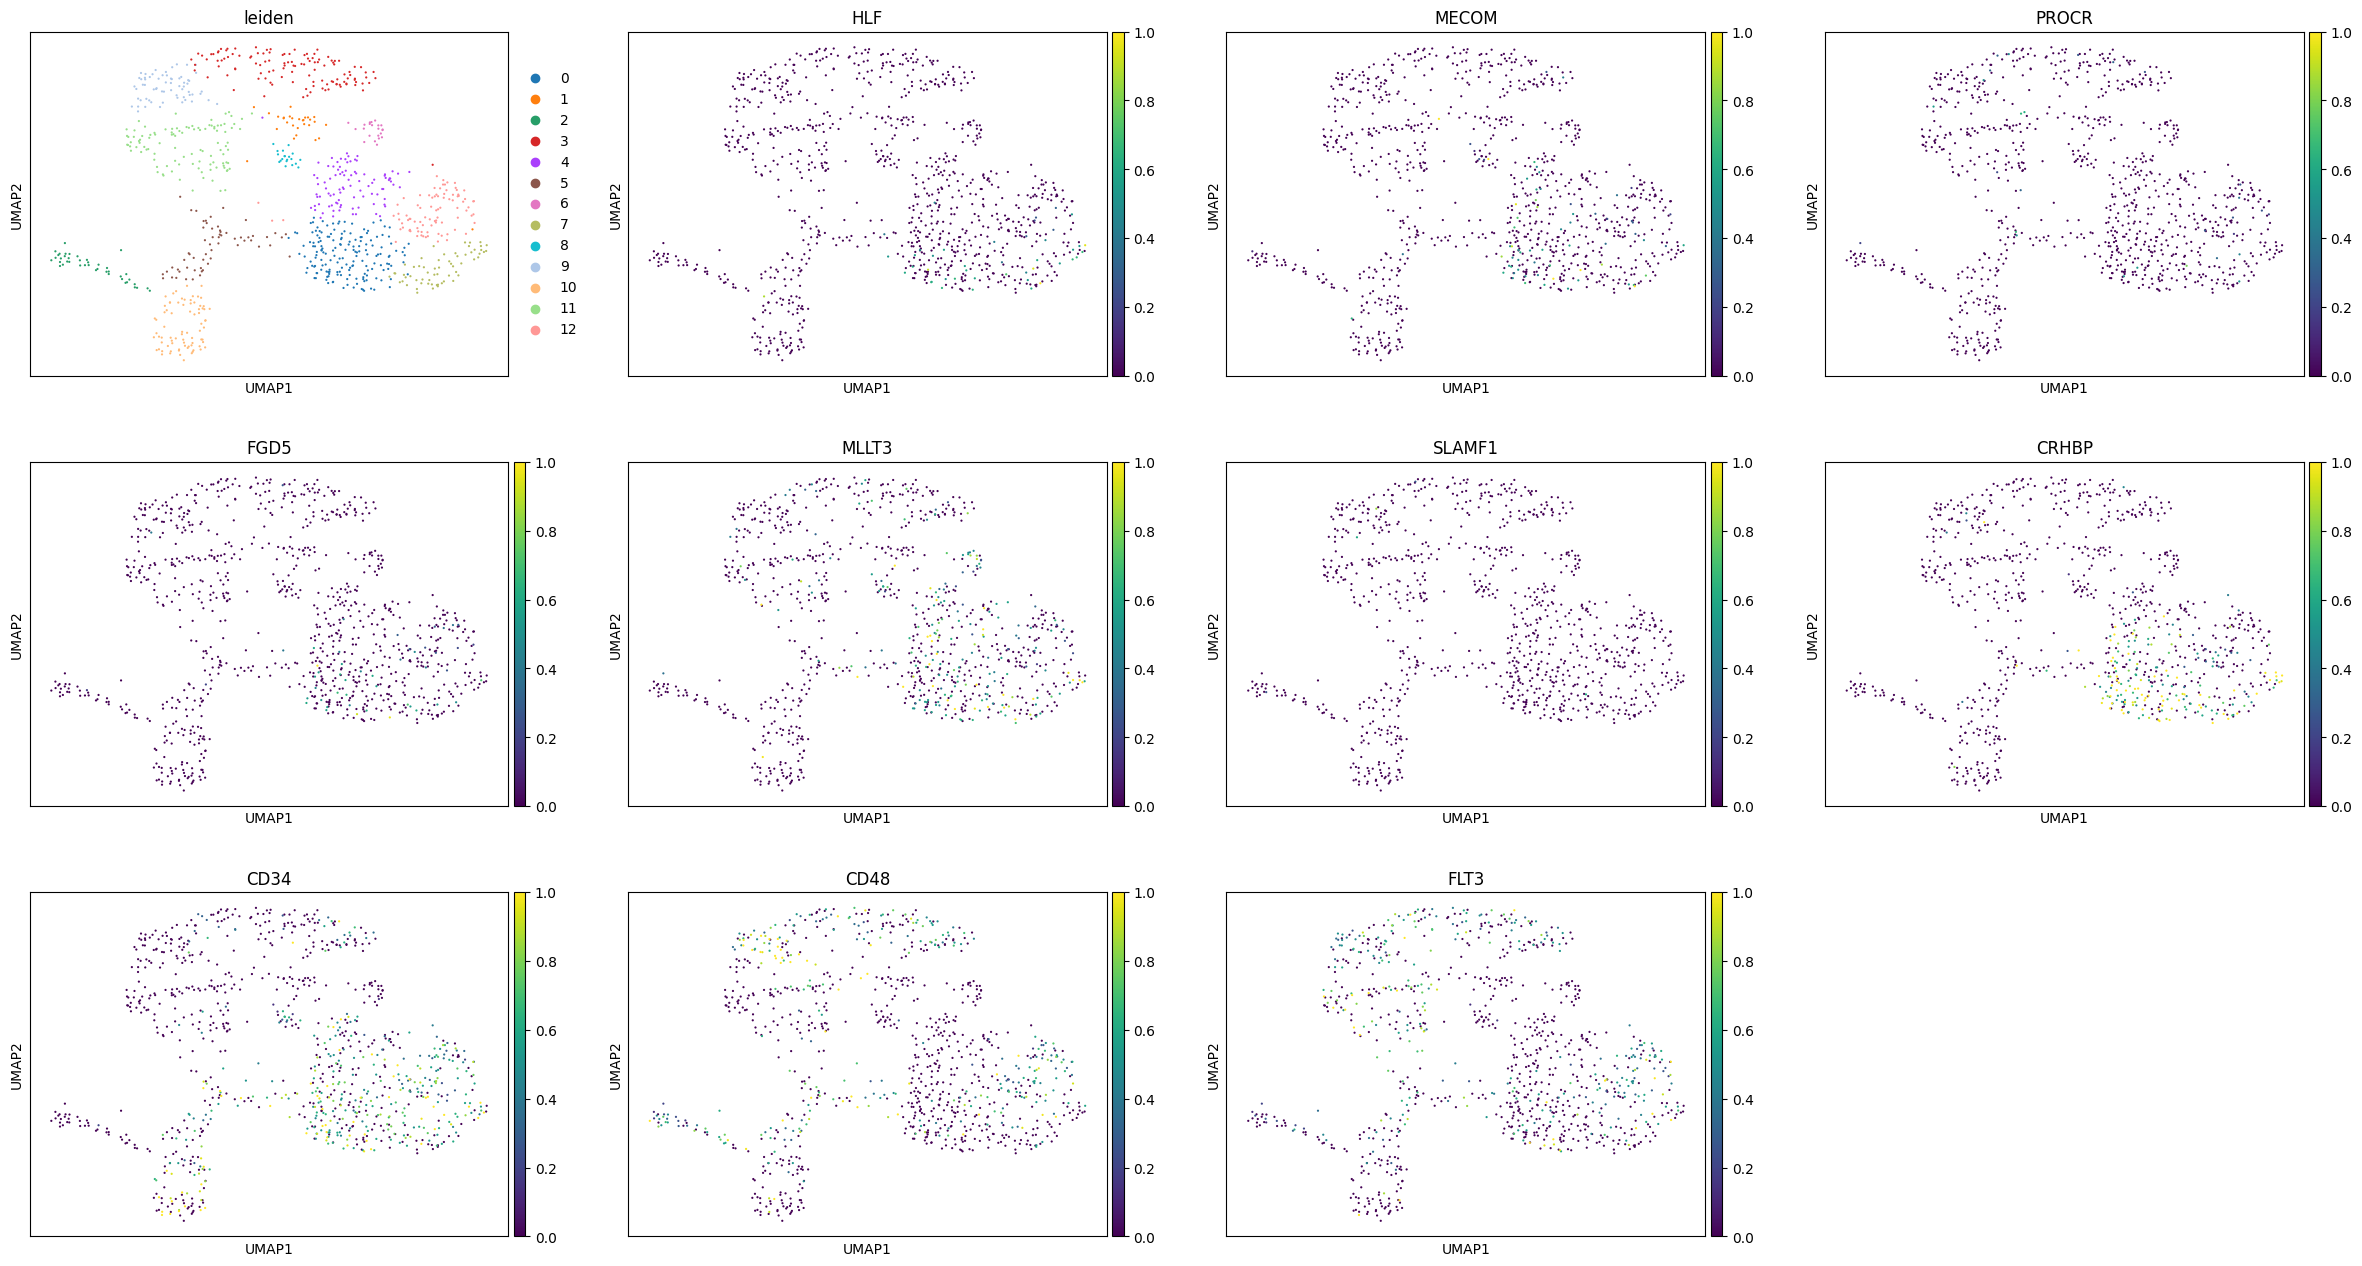

=== Day 90 ===
Atlas HVGs used for BCG d90: 998 / 1000
BCG d90: 1246 cells, 10 Leiden clusters


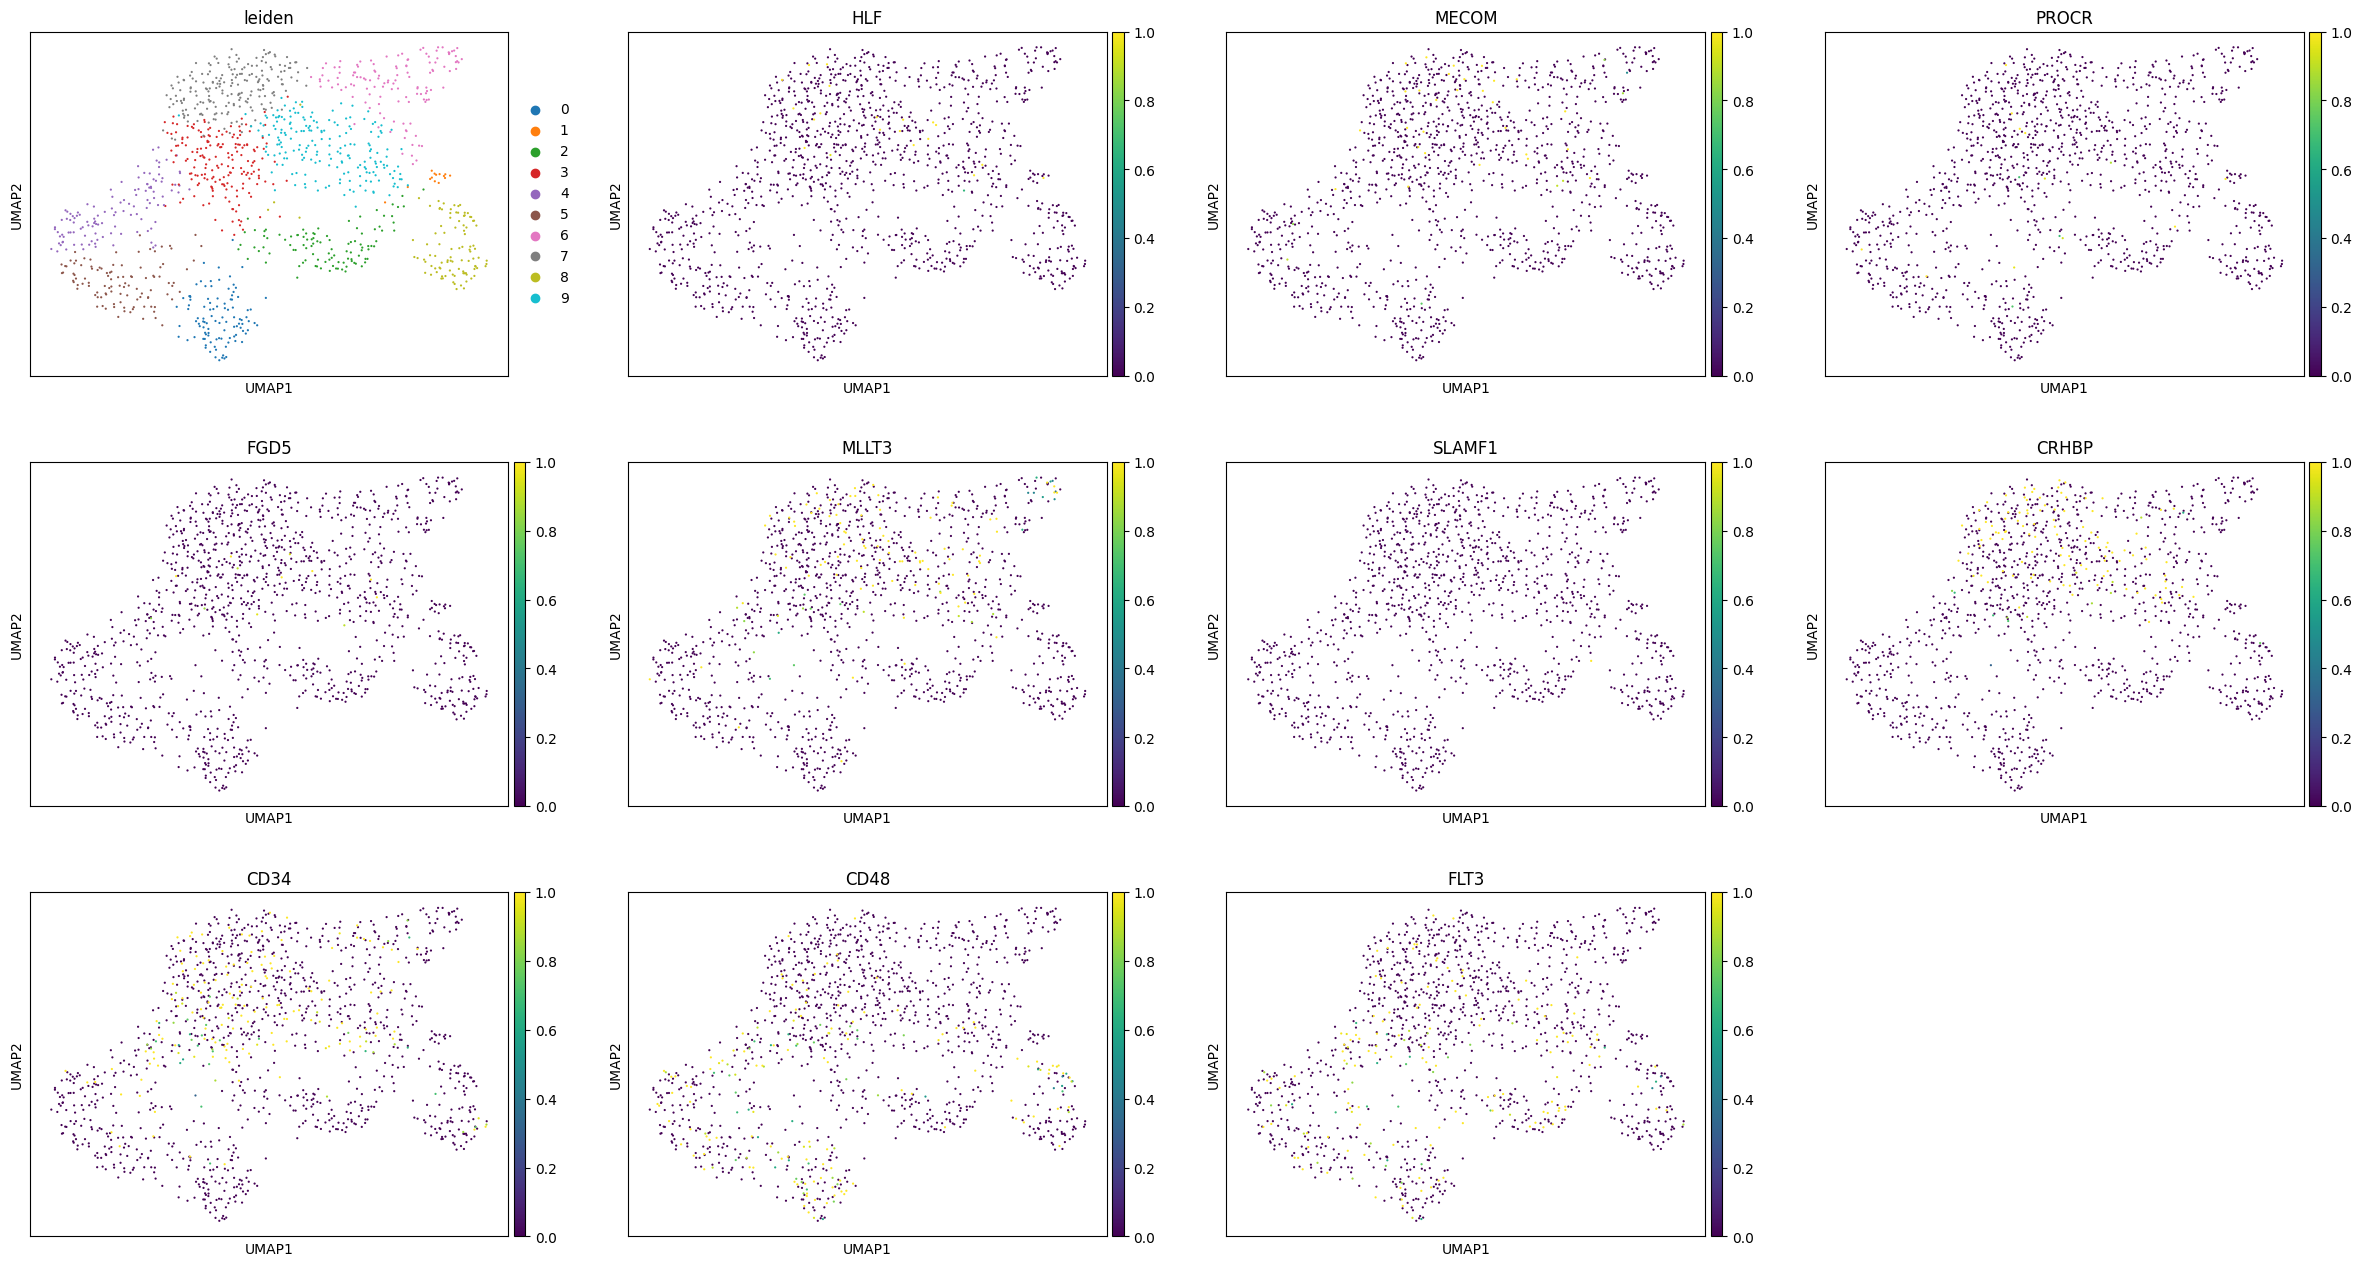

In [15]:
import random

RANDOM_SEED = 0
LTHSC_GENES = ["HLF", "MECOM", "PROCR", "FGD5", "MLLT3", "SLAMF1", "CRHBP"]
PLOT_GENES = LTHSC_GENES + ["CD34", "CD48", "FLT3"]


def preprocess_and_cluster_bcg(adata, *, day, label, random_seed=RANDOM_SEED):
    np.random.seed(random_seed)
    random.seed(random_seed)
    a = adata.copy()
    a.obs["day"] = day
    a.layers["counts"] = a.X.copy()
    sc.pp.normalize_total(a, target_sum=1e4)
    sc.pp.log1p(a)
    n_hvg = int(a.var["highly_variable"].sum())
    print(f"Atlas HVGs used for {label}: {n_hvg} / {len(ATLAS_HVG_GENES)}")
    sc.tl.pca(a, random_state=random_seed)
    sc.pp.neighbors(a, random_state=random_seed)
    sc.tl.umap(a, random_state=random_seed)
    sc.tl.leiden(a, flavor="igraph", n_iterations=2, random_state=random_seed)
    print(f"{label}: {a.n_obs} cells, {a.obs['leiden'].nunique()} Leiden clusters")
    genes = [g for g in PLOT_GENES if g in a.var_names]
    sc.pl.umap(a, color=["leiden"] + genes, size=10, vmax=1.0)
    return a


print("=== Day 0 ===")
adata_d0 = preprocess_and_cluster_bcg(adata_d0, day=0, label="BCG d0")
print("=== Day 90 ===")
adata_d90 = preprocess_and_cluster_bcg(adata_d90, day=90, label="BCG d90")

In [16]:
def select_lthsc_by_marker_score(adata, genes=LTHSC_GENES, *, z_thresh=1.0, label=""):
    """Pick Leiden cluster(s) enriched for LT-HSC markers (mean module score)."""
    present = [g for g in genes if g in adata.var_names]
    sc.tl.score_genes(adata, present, score_name="score_lthsc", use_raw=False)
    means = adata.obs.groupby("leiden", observed=True)["score_lthsc"].mean().sort_values(ascending=False)
    z = (means - means.mean()) / (means.std(ddof=0) + 1e-8)
    selected = means.index[z >= z_thresh].tolist()
    if not selected:
        selected = [means.index[0]]
    print(f"\n{label} cluster mean score_lthsc (z):")
    for cl in means.index:
        print(f"  {cl}: {means[cl]:.3f} (z={z[cl]:.2f}){'  ← LT-HSC' if cl in selected else ''}")
    print(f"{label} selected clusters: {selected} ({present})")
    return selected


D0_LTHSC_CLUSTERS = select_lthsc_by_marker_score(adata_d0, label="d0")
D90_LTHSC_CLUSTERS = select_lthsc_by_marker_score(adata_d90, label="d90")

d0_lthsc = adata_d0[adata_d0.obs["leiden"].isin(D0_LTHSC_CLUSTERS)].copy()
d90_lthsc = adata_d90[adata_d90.obs["leiden"].isin(D90_LTHSC_CLUSTERS)].copy()

for a in (d0_lthsc, d90_lthsc):
    a.obs["cell_type"] = "LT-HSC"
    a.obs["shared_cell_type"] = "LT-HSC"

print(f"\nDay 0 LT-HSC: {d0_lthsc.n_obs}")
print(f"Day 90 LT-HSC: {d90_lthsc.n_obs}")
d0_lthsc, d90_lthsc


d0 cluster mean score_lthsc (z):
  7: 0.120 (z=2.40)  ← LT-HSC
  0: 0.088 (z=1.88)  ← LT-HSC
  4: 0.013 (z=0.67)
  12: -0.026 (z=0.04)
  6: -0.029 (z=0.01)
  8: -0.052 (z=-0.38)
  5: -0.060 (z=-0.50)
  1: -0.068 (z=-0.62)
  9: -0.068 (z=-0.62)
  10: -0.069 (z=-0.64)
  3: -0.070 (z=-0.66)
  11: -0.077 (z=-0.77)
  2: -0.079 (z=-0.81)
d0 selected clusters: ['7', '0'] (['HLF', 'MECOM', 'PROCR', 'FGD5', 'MLLT3', 'SLAMF1', 'CRHBP'])

d90 cluster mean score_lthsc (z):
  9: 0.079 (z=1.99)  ← LT-HSC
  7: 0.070 (z=1.79)  ← LT-HSC
  3: 0.004 (z=0.26)
  6: -0.017 (z=-0.24)
  1: -0.018 (z=-0.27)
  4: -0.028 (z=-0.49)
  2: -0.030 (z=-0.54)
  0: -0.039 (z=-0.75)
  5: -0.040 (z=-0.79)
  8: -0.048 (z=-0.96)
d90 selected clusters: ['9', '7'] (['HLF', 'MECOM', 'PROCR', 'FGD5', 'MLLT3', 'SLAMF1', 'CRHBP'])

Day 0 LT-HSC: 230
Day 90 LT-HSC: 392


(AnnData object with n_obs × n_vars = 230 × 36601
     obs: 'capture', 'capture_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'day', 'leiden', 'score_lthsc', 'cell_type', 'shared_cell_type'
     var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'ensembl_id', 'highly_variable'
     uns: 'log1p', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors'
     obsm: 'X_pca', 'X_umap'
     varm: 'PCs'
     layers: 'counts'
     obsp: 'distances', 'connectivities',
 AnnData object with n_obs × n_vars = 392 × 36601
     obs: 'capture', 'capture_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'day', 'leiden', 'score_lthsc', 'cell_type', 'shared_cell_type'
     var: 'gene_ids', 'feature_

### scANVI reference mapping (BCG → human atlas)

Isolate **atlas LT-HSCs** from Tabula Sapiens HSPCs (same quantitative marker score as BCG), project BCG + atlas LT-HSCs onto `ATLAS_HVG` ENSG columns, then follow e22: train SCVI→SCANVI on atlas LT-HSC (+ remaining HSPCs as `HSPC` for label diversity), map untreated **d0** and treated **d90** LT-HSCs as labeled queries, and decode expression conditioned on the **atlas** batch into `.layers['counts']`.


Marker ENSGs: 7/7 LT-HSC, 10/10 plot
Atlas HSPC: 613 cells, 7 clusters


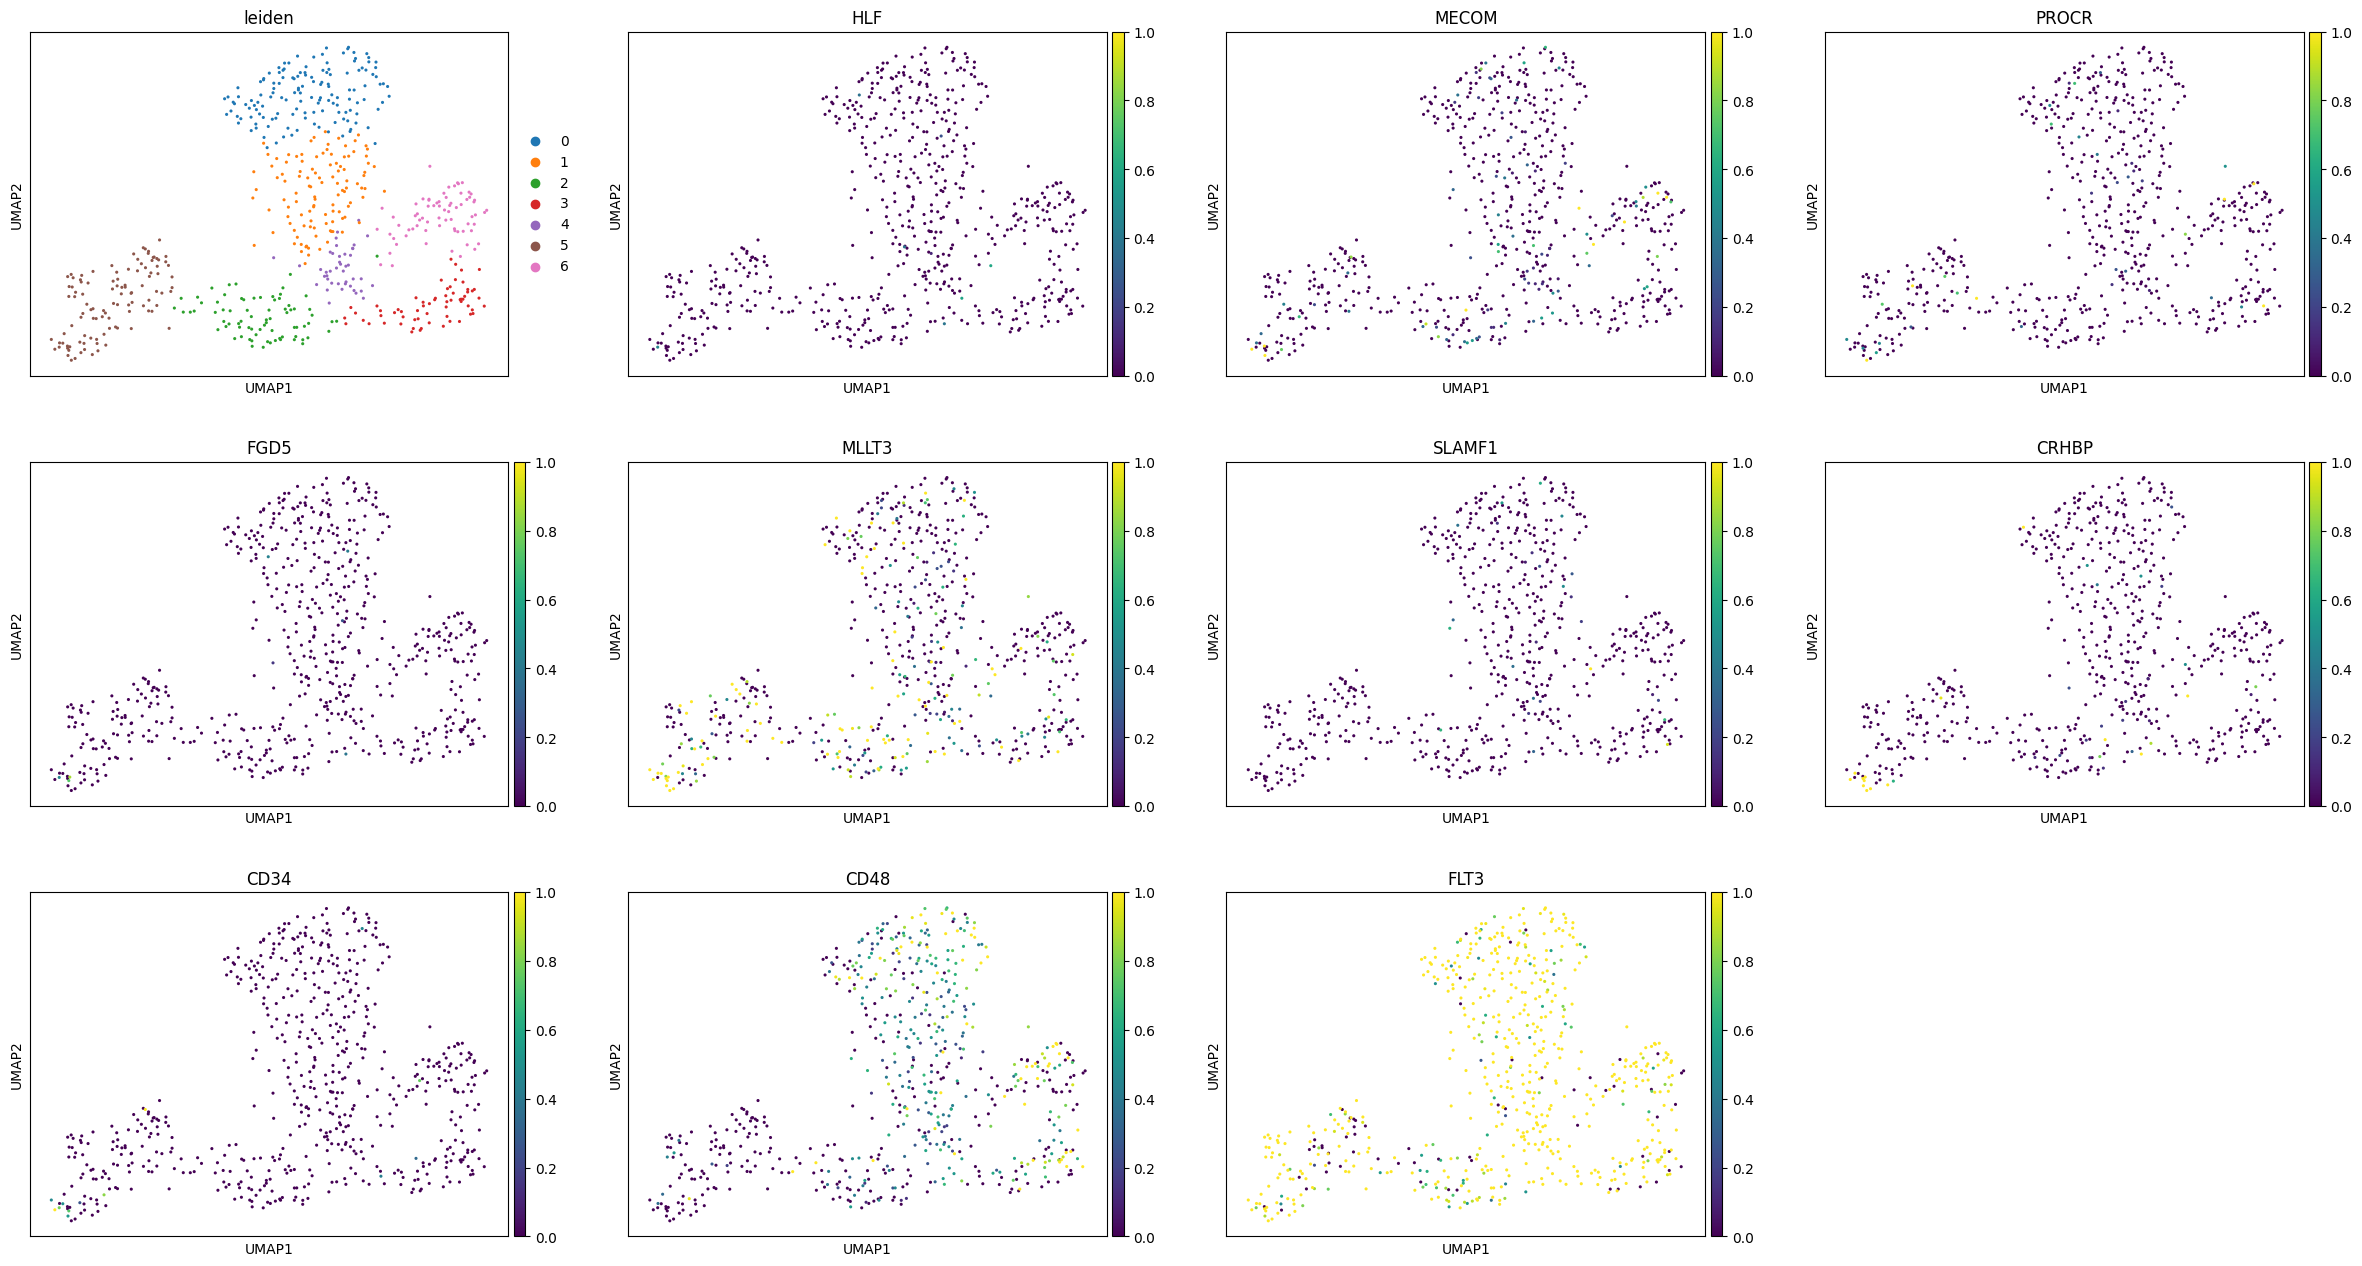


atlas HSPC cluster mean score_lthsc (z):
  5: 0.057 (z=1.99)  ← LT-HSC
  2: 0.013 (z=0.69)
  6: -0.013 (z=-0.09)
  4: -0.013 (z=-0.10)
  3: -0.020 (z=-0.29)
  0: -0.042 (z=-0.93)
  1: -0.053 (z=-1.26)
atlas HSPC selected clusters: ['5'] (['ENSG00000108924', 'ENSG00000085276', 'ENSG00000101000', 'ENSG00000154783', 'ENSG00000171843', 'ENSG00000117090', 'ENSG00000145708'])
Atlas LT-HSC: 107; other HSPC: 506


In [24]:
# Load Tabula Sapiens counts; isolate bone-marrow HSPCs → atlas LT-HSCs
# Map marker symbols → ENSG via BCG features (atlas var_names are ENSG)
SYM2ENSG = {
    str(sym): strip_ensembl_gene_id(str(eid))
    for sym, eid in zip(d0_lthsc.var_names, d0_lthsc.var["gene_ids"])
}
LTHSC_ENSG = [SYM2ENSG[g] for g in LTHSC_GENES if g in SYM2ENSG]
PLOT_ENSG = [SYM2ENSG[g] for g in PLOT_GENES if g in SYM2ENSG]
ENSG2SYM = {e: s for s, e in SYM2ENSG.items()}
print(f"Marker ENSGs: {len(LTHSC_ENSG)}/{len(LTHSC_GENES)} LT-HSC, {len(PLOT_ENSG)}/{len(PLOT_GENES)} plot")

human_full = sc.read_h5ad(HUMAN_H5AD)
human = human_full.raw.to_adata()
human.obs = human_full.obs.copy()
human.var_names = [strip_ensembl_gene_id(x) for x in human.var_names.astype(str)]
human.var_names_make_unique()

atlas_hspc = human[
    (human.obs["cell_type"] == "hematopoietic precursor cell")
    & (human.obs["tissue"] == "bone marrow")
    & (human.obs["assay"] == "10x 3' v3")
].copy()
atlas_hspc.layers["counts"] = atlas_hspc.X.copy()
atlas_hspc.obs["study"] = "atlas"

# Light preprocess for clustering / marker scoring (keep counts layer)
sc.pp.normalize_total(atlas_hspc, target_sum=1e4)
sc.pp.log1p(atlas_hspc)
atlas_hspc.var["highly_variable"] = atlas_hspc.var_names.isin(ATLAS_HVG_GENES)
sc.tl.pca(atlas_hspc, random_state=RANDOM_SEED)
sc.pp.neighbors(atlas_hspc, random_state=RANDOM_SEED)
sc.tl.umap(atlas_hspc, random_state=RANDOM_SEED)
sc.tl.leiden(atlas_hspc, flavor="igraph", n_iterations=2, random_state=RANDOM_SEED, resolution=1.0)

# Plot with gene symbols as titles
plot_genes = [e for e in PLOT_ENSG if e in atlas_hspc.var_names]
print(f"Atlas HSPC: {atlas_hspc.n_obs} cells, {atlas_hspc.obs['leiden'].nunique()} clusters")
sc.pl.umap(
    atlas_hspc,
    color=["leiden"] + plot_genes,
    size=20,
    vmax=1.0,
    title=["leiden"] + [ENSG2SYM.get(e, e) for e in plot_genes],
)

ATLAS_LTHSC_CLUSTERS = select_lthsc_by_marker_score(
    atlas_hspc, genes=LTHSC_ENSG, label="atlas HSPC"
)
atlas_lthsc = atlas_hspc[atlas_hspc.obs["leiden"].isin(ATLAS_LTHSC_CLUSTERS)].copy()
atlas_hspc_other = atlas_hspc[~atlas_hspc.obs["leiden"].isin(ATLAS_LTHSC_CLUSTERS)].copy()
atlas_lthsc.obs["cell_type"] = "LT-HSC"
atlas_lthsc.obs["shared_cell_type"] = "LT-HSC"
atlas_hspc_other.obs["cell_type"] = "HSPC"
atlas_hspc_other.obs["shared_cell_type"] = "HSPC"
# Restore counts into .X for projection (log1p was only for clustering)
atlas_lthsc.X = atlas_lthsc.layers["counts"].copy()
atlas_hspc_other.X = atlas_hspc_other.layers["counts"].copy()
print(f"Atlas LT-HSC: {atlas_lthsc.n_obs}; other HSPC: {atlas_hspc_other.n_obs}")


In [25]:
from scipy import sparse


def project_to_atlas_hvg(adata, *, label=""):
    """Project human AnnData onto ATLAS_HVG ENSG columns (zero-fill missing)."""
    names = [strip_ensembl_gene_id(x) for x in adata.var_names.astype(str)]
    if sum(n.startswith("ENSG") for n in names[:50]) >= 40:
        ensg_per_col = names
    elif "gene_ids" in adata.var.columns:
        ensg_per_col = adata.var["gene_ids"].astype(str).map(strip_ensembl_gene_id).tolist()
    elif "ensembl_id" in adata.var.columns:
        ensg_per_col = adata.var["ensembl_id"].astype(str).map(strip_ensembl_gene_id).tolist()
    else:
        raise ValueError(f"{label}: cannot resolve ENSG ids")

    ensg2col = {}
    for j, e in enumerate(ensg_per_col):
        if e and e.startswith("ENSG") and e not in ensg2col:
            ensg2col[e] = j

    X_src = adata.layers["counts"] if "counts" in adata.layers else adata.X
    X_src = X_src.toarray() if sparse.issparse(X_src) else np.asarray(X_src)
    X_src = np.asarray(X_src, dtype=np.float32)

    n_genes = len(ATLAS_HVG_GENES)
    X_new = np.zeros((adata.n_obs, n_genes), dtype=np.float32)
    present = 0
    for j, ensg in enumerate(ATLAS_HVG_GENES):
        ci = ensg2col.get(ensg)
        if ci is None:
            continue
        present += 1
        X_new[:, j] = X_src[:, ci]

    var = pd.DataFrame(index=pd.Index(ATLAS_HVG_GENES, name="ensg"))
    var["highly_variable"] = True
    out = ad.AnnData(X=X_new, obs=adata.obs.copy(), var=var)
    out.layers["counts"] = X_new.copy()
    out.uns["atlas_hvg"] = {
        "flavor": FLAVOR,
        "source": ATLAS_HVG_H5AD,
        "n_present": int(present),
        "n_target": int(n_genes),
        "label": label,
    }
    print(f"  project_to_atlas_hvg({label}): coverage {present}/{n_genes} ({100*present/n_genes:.1f}%)")
    return out


d0_lthsc_hvg = project_to_atlas_hvg(d0_lthsc, label="bcg_d0_lthsc")
d90_lthsc_hvg = project_to_atlas_hvg(d90_lthsc, label="bcg_d90_lthsc")
atlas_lthsc_hvg = project_to_atlas_hvg(atlas_lthsc, label="atlas_lthsc")
atlas_hspc_other_hvg = project_to_atlas_hvg(atlas_hspc_other, label="atlas_hspc_other")
assert list(d0_lthsc_hvg.var_names) == ATLAS_HVG_GENES


  project_to_atlas_hvg(bcg_d0_lthsc): coverage 998/1000 (99.8%)
  project_to_atlas_hvg(bcg_d90_lthsc): coverage 998/1000 (99.8%)
  project_to_atlas_hvg(atlas_lthsc): coverage 1000/1000 (100.0%)
  project_to_atlas_hvg(atlas_hspc_other): coverage 1000/1000 (100.0%)


In [26]:
import warnings
from scvi.model import SCVI, SCANVI

SCVI_MAX_EPOCHS = 100
SCANVI_MAX_EPOCHS = 20
QUERY_MAX_EPOCHS = 50
N_LATENT = 20


def ensure_counts(adata):
    a = adata.copy()
    if "counts" not in a.layers:
        a.layers["counts"] = a.X.copy()
    return a


ref_hvg = list(ATLAS_HVG_GENES)
print(f"Genes for scANVI (all ATLAS_HVG_H5AD genes): {len(ref_hvg)}")

# Reference: atlas LT-HSC + other HSPC (label diversity, like e22 MPP3/MPP4)
ref = ensure_counts(
    ad.concat(
        [atlas_lthsc_hvg[:, ref_hvg].copy(), atlas_hspc_other_hvg[:, ref_hvg].copy()],
        join="inner",
        index_unique="-",
    )
)
ref.obs["study"] = "atlas"
ref.obs["cell_type_scanvi"] = ref.obs["cell_type"].astype(str)

SCVI.setup_anndata(ref, layer="counts", batch_key="study")
vae = SCVI(ref, n_latent=N_LATENT)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    vae.train(max_epochs=SCVI_MAX_EPOCHS, early_stopping=True)

scanvi_model = SCANVI.from_scvi_model(
    vae, unlabeled_category="Unknown", labels_key="cell_type_scanvi"
)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    scanvi_model.train(max_epochs=SCANVI_MAX_EPOCHS, early_stopping=True)


def map_lthsc_to_atlas_counts(query_adata, study_label, query_model_train_epochs=QUERY_MAX_EPOCHS):
    """Map query LT-HSCs with scANVI; write atlas-batch counts into .layers['counts']."""
    q = ensure_counts(query_adata[:, ref_hvg].copy())
    q.obs["study"] = study_label
    q.obs["cell_type"] = "LT-HSC"
    q.obs["cell_type_scanvi"] = "LT-HSC"  # semi-supervised (untreated d0 anchors the label)
    q.layers["counts_original"] = q.layers["counts"].copy()

    SCANVI.prepare_query_anndata(q, scanvi_model)
    q_model = SCANVI.load_query_data(q, scanvi_model)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        q_model.train(max_epochs=query_model_train_epochs)

    freq = q_model.get_normalized_expression(
        adata=q, transform_batch="atlas", library_size=1.0, return_numpy=True
    )
    lib = np.asarray(q.layers["counts_original"].sum(axis=1)).ravel()
    counts_atlas = np.maximum(np.asarray(freq) * lib[:, None], 0).astype(np.float32)
    q.layers["counts"] = sparse.csr_matrix(counts_atlas)
    q.obsm["X_scANVI"] = q_model.get_latent_representation()
    q.uns["scanvi_mapping"] = {
        "reference": "atlas LT-HSC + HSPC",
        "n_hvg": len(ref_hvg),
        "transform_batch": "atlas",
        "counts_layer": "decoded to atlas batch, scaled by original library size",
        "query_study": study_label,
    }
    return q


# Learn / apply with untreated d0 LT-HSCs, then apply to treated d90
bcg_control_scanvi = map_lthsc_to_atlas_counts(d0_lthsc_hvg, "bcg_control")
bcg_treated_scanvi = map_lthsc_to_atlas_counts(d90_lthsc_hvg, "bcg")

bcg_control_scanvi.write_h5ad(CONTROL_OUT)
bcg_treated_scanvi.write_h5ad(TREATED_OUT)
print(f"Wrote {CONTROL_OUT}  n_obs={bcg_control_scanvi.n_obs}")
print(f"Wrote {TREATED_OUT}  n_obs={bcg_treated_scanvi.n_obs}")
bcg_control_scanvi, bcg_treated_scanvi


Genes for scANVI (all ATLAS_HVG_H5AD genes): 1000


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Epoch 100/100: 100%|██████████| 100/100 [00:11<00:00,  9.62it/s, v_num=1, train_loss=827]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [00:11<00:00,  8.88it/s, v_num=1, train_loss=827]
INFO     Training for 20 epochs.                                                                                   


...

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speci ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Epoch 50/50: 100%|██████████| 50/50 [00:03<00:00, 15.53it/s, v_num=1, train_loss=770]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 50/50: 100%|██████████| 50/50 [00:03<00:00, 15.42it/s, v_num=1, train_loss=770]
Wrote /n/holylabs/mooney_lab/Lab/joshprice/speciesOT/tb/data/human_bcg/bcg_control_scanvi_082626.h5ad  n_obs=230
Wrote /n/holylabs/mooney_lab/Lab/joshprice/speciesOT/tb/data/human_bcg/bcg_treated_scanvi_082626.h5ad  n_obs=392


(AnnData object with n_obs × n_vars = 230 × 1000
     obs: 'capture', 'capture_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'day', 'leiden', 'score_lthsc', 'cell_type', 'shared_cell_type', 'study', 'cell_type_scanvi', '_scvi_batch', '_scvi_labels'
     var: 'highly_variable'
     uns: 'atlas_hvg', '_scvi_uuid', '_scvi_manager_uuid', 'scanvi_mapping'
     obsm: 'X_scANVI'
     layers: 'counts', 'counts_original',
 AnnData object with n_obs × n_vars = 392 × 1000
     obs: 'capture', 'capture_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'day', 'leiden', 'score_lthsc', 'cell_type', 'shared_cell_type', 'study', 'cell_type_scanvi', '_scvi_batch', '_scvi_labels'
     var: 'highly_variable'
     uns: 'atlas_hvg', '_scvi_uuid', '_scvi_manager_uuid', 'scanvi_m

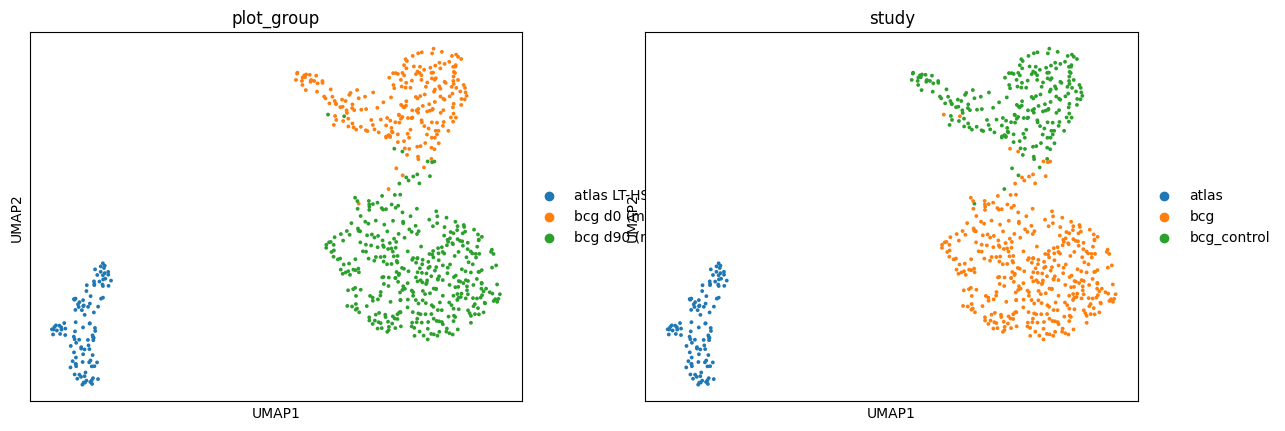

plot_group
bcg d90 (mapped)    392
bcg d0 (mapped)     230
atlas LT-HSC        107
Name: count, dtype: int64


In [27]:
# Latent-space UMAP: atlas LT-HSC vs mapped BCG control / treated
ref.obsm["X_scANVI"] = scanvi_model.get_latent_representation()
atlas_lat = ref[ref.obs["cell_type_scanvi"] == "LT-HSC"].copy()
atlas_lat.obs["plot_group"] = "atlas LT-HSC"
ctrl = bcg_control_scanvi.copy()
ctrl.obs["plot_group"] = "bcg d0 (mapped)"
trt = bcg_treated_scanvi.copy()
trt.obs["plot_group"] = "bcg d90 (mapped)"

combined = ad.concat([atlas_lat, ctrl, trt], join="outer", index_unique="-")
sc.pp.neighbors(combined, use_rep="X_scANVI", random_state=RANDOM_SEED)
sc.tl.umap(combined, random_state=RANDOM_SEED)
sc.pl.umap(combined, color=["plot_group", "study"], size=30)
print(combined.obs["plot_group"].value_counts())


In [ ]:
# Save scANVI-mapped BCG LT-HSCs (atlas-decoded counts in .layers['counts'])
CONTROL_OUT = "/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/tb/data/human_bcg/bcg_control_scanvi_082626.h5ad"
TREATED_OUT = "/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/tb/data/human_bcg/bcg_treated_scanvi_082626.h5ad"

os.makedirs(os.path.dirname(CONTROL_OUT), exist_ok=True)
bcg_control_scanvi.write_h5ad(CONTROL_OUT)
bcg_treated_scanvi.write_h5ad(TREATED_OUT)

print(f"Wrote {CONTROL_OUT}")
print(f"  n_obs={bcg_control_scanvi.n_obs}, n_vars={bcg_control_scanvi.n_vars}, layers={list(bcg_control_scanvi.layers)}")
print(f"Wrote {TREATED_OUT}")
print(f"  n_obs={bcg_treated_scanvi.n_obs}, n_vars={bcg_treated_scanvi.n_vars}, layers={list(bcg_treated_scanvi.layers)}")


In [28]:
combined

AnnData object with n_obs × n_vars = 729 × 1000
    obs: 'donor_id', 'tissue_in_publication', 'anatomical_position', 'method', 'cdna_plate', 'library_plate', 'notes', 'cdna_well', 'assay_ontology_term_id', 'sample_id', 'replicate', '10X_run', 'ambient_removal', 'donor_method', 'donor_assay', 'donor_tissue', 'donor_tissue_assay', 'cell_type_ontology_term_id', 'compartment', 'broad_cell_class', 'free_annotation', 'manually_annotated', 'published_2022', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ercc', 'pct_counts_ercc', '_scvi_batch', '_scvi_labels', 'scvi_leiden_donorassay_full', 'ethnicity_original', 'scvi_leiden_res05_compartment', 'sample_number', 'suspension_type', 'tissue_type', 'disease_ontology_term_id', 'is_primary_data', 'tissue_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'develo